<a href="https://colab.research.google.com/github/pavinruthvick/pavinruthvick/blob/main/Class_Activity_SVM_Pavin_Ruthvick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
# Step 2: Load Dataset

data_df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [ ]:
# Step 3: Basic Data Exploration

print(" First few rows ")
print(data_df.head())

print("\n Dataset Info ")
print(data_df.info())

print("\n Statistical Summary ")
print(data_df.describe())

 First few rows 
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6       

In [ ]:
# Step 4: Missing Values

print(" Missing Values ")
print(data_df.isnull().sum())

 Missing Values 
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
# Step 5: Class Distribution

print(" Class Distribution (DEATH_EVENT) ")
print(data_df["DEATH_EVENT"].value_counts())

 Class Distribution (DEATH_EVENT) 
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


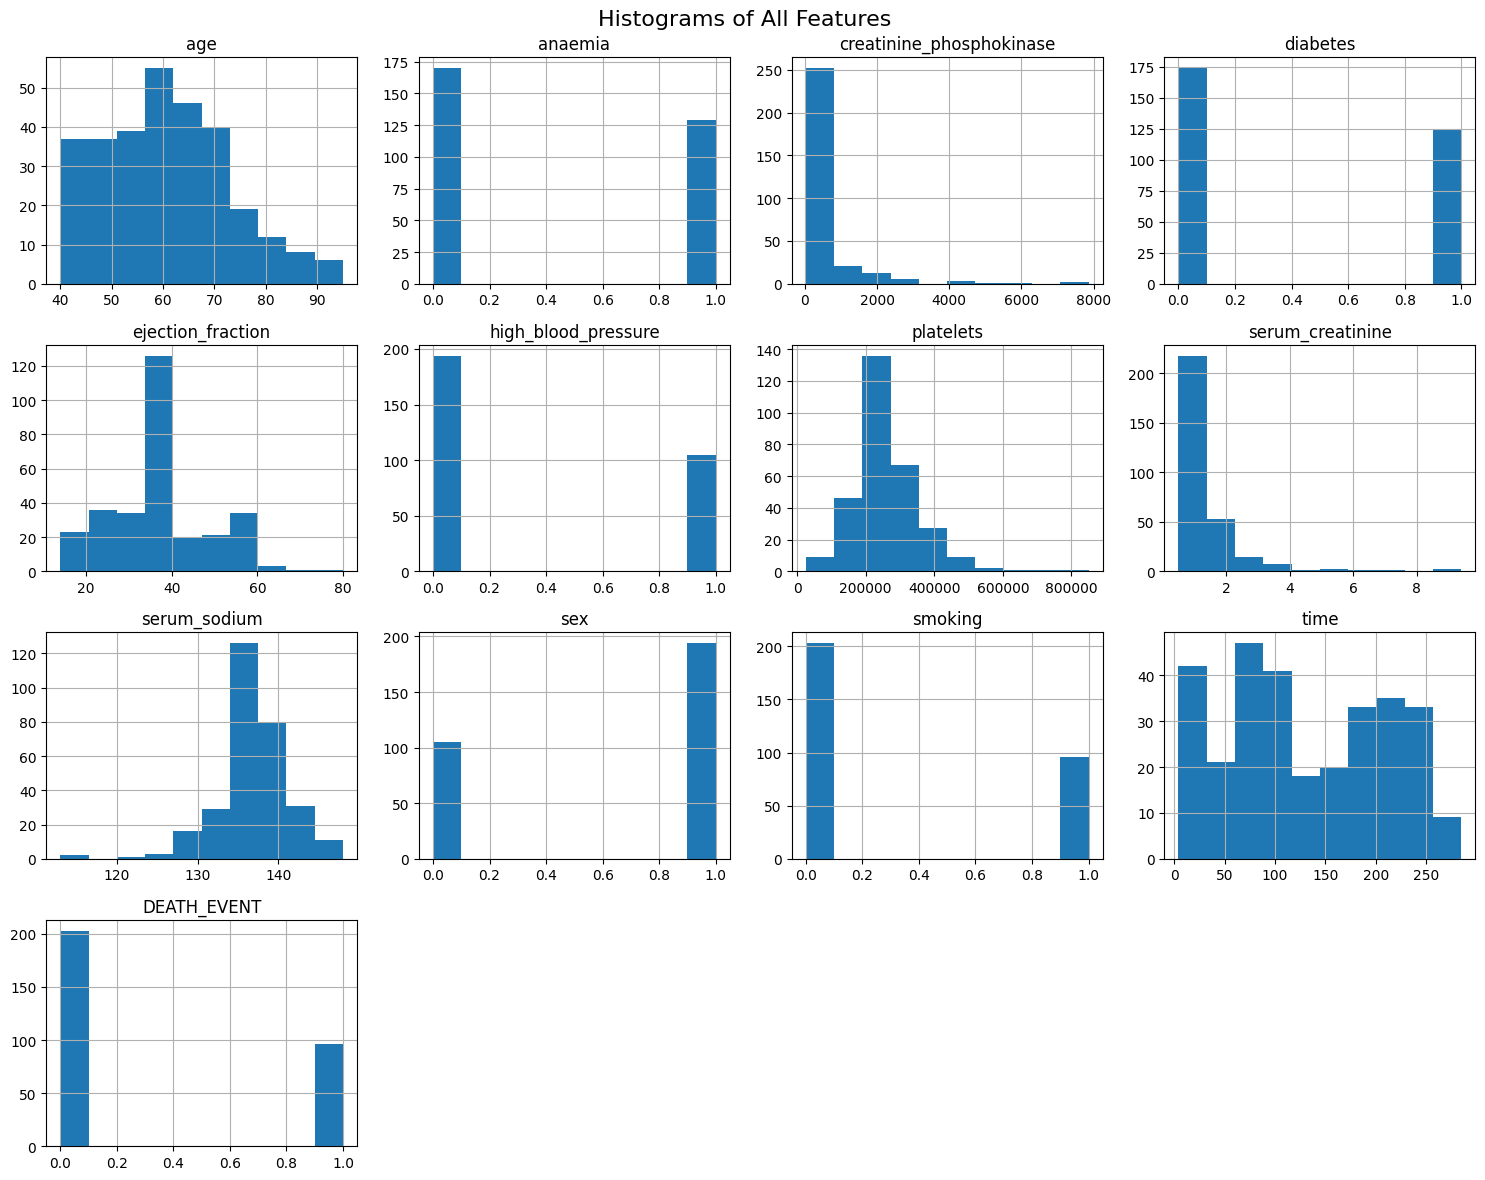

In [ ]:
# Step 6: Histogram Plot

data_df.hist(figsize=(15, 12))
plt.suptitle("Histograms of All Features", fontsize=16)
plt.tight_layout()
plt.show()

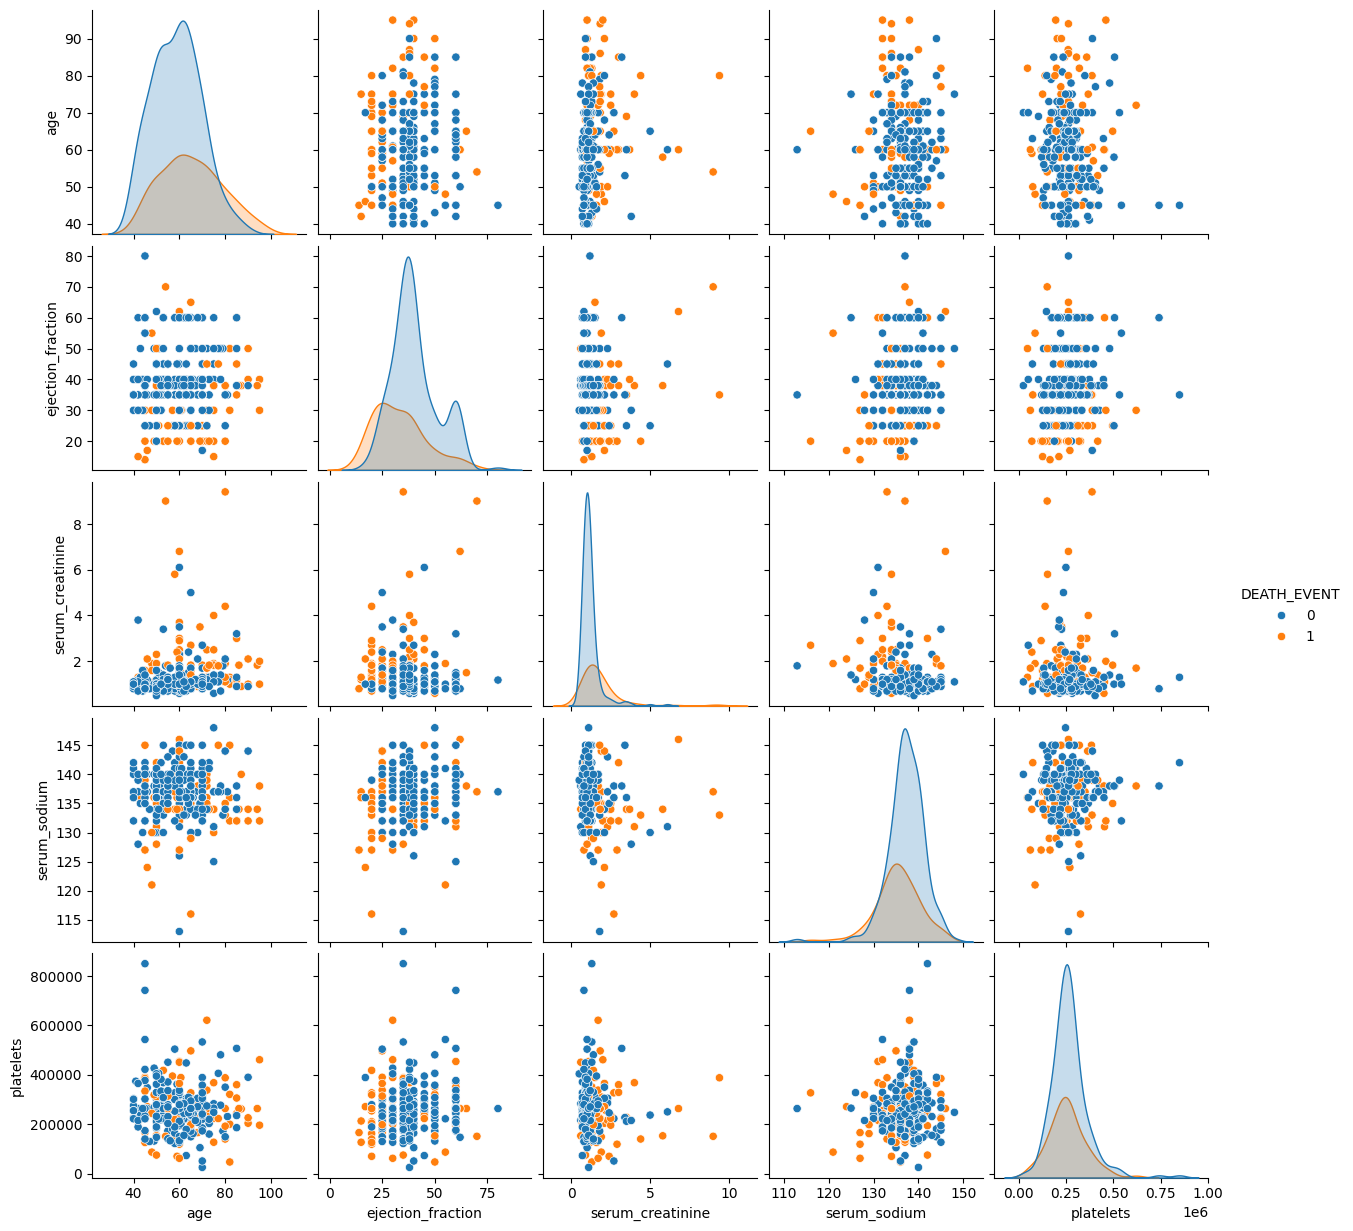

In [ ]:
cols = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'platelets', 'DEATH_EVENT']
sns.pairplot(data_df[cols], hue="DEATH_EVENT")
plt.show()

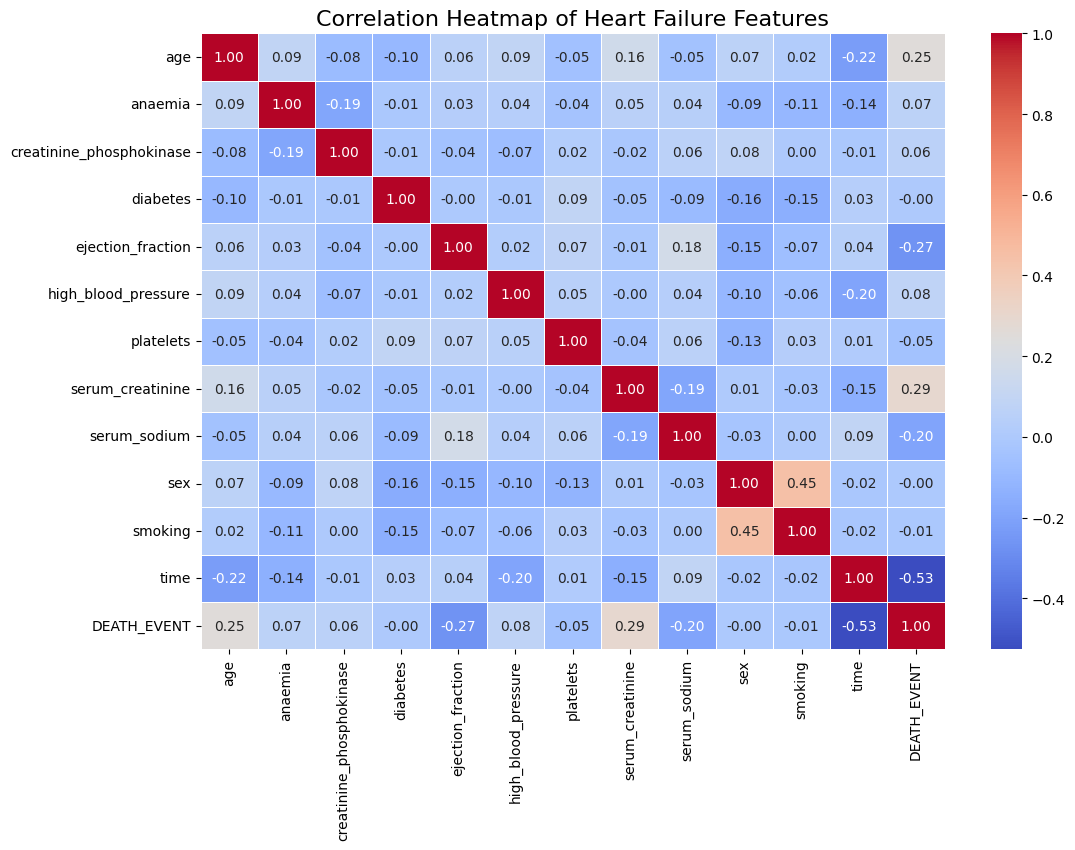

In [ ]:

# Step 7: Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    data_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Heart Failure Features", fontsize=16)
plt.show()

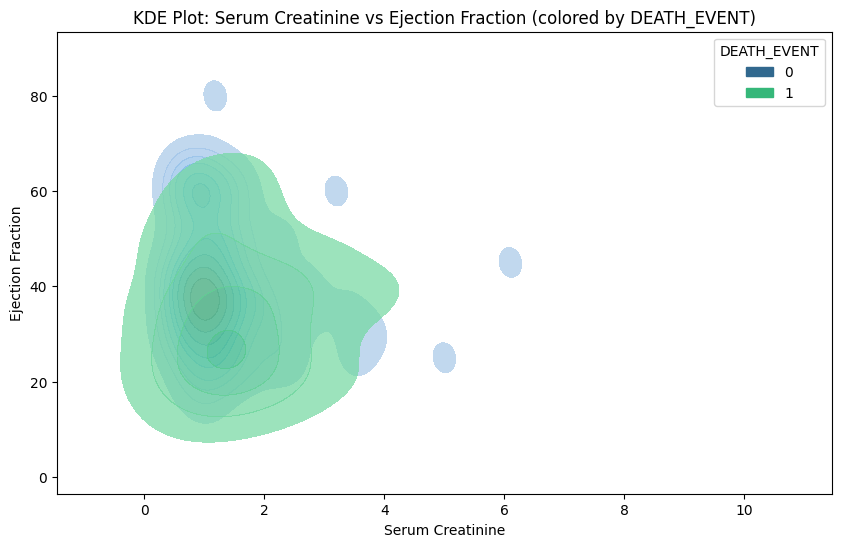

In [ ]:
# Step 8: KDE Plot

plt.figure(figsize=(10, 6))
sns.kdeplot(
    x = data_df["serum_creatinine"],
    y = data_df["ejection_fraction"],
    hue = data_df["DEATH_EVENT"],
    fill = True,
    palette="viridis",
    alpha=0.7
)
plt.title("KDE Plot: Serum Creatinine vs Ejection Fraction (colored by DEATH_EVENT)")
plt.xlabel("Serum Creatinine")
plt.ylabel("Ejection Fraction")
plt.show()

In [ ]:
# Step 9: Feature & Target Split

X = data_df.drop("DEATH_EVENT", axis=1)
y = data_df["DEATH_EVENT"]

print(f"X shape: {X.shape} | y shape: {y.shape}")

X shape: (299, 12) | y shape: (299,)


In [ ]:
# Step 10: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 239
Testing samples : 60


In [ ]:
# Step 11: Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [ ]:
# Step 12: Train SVM Model

model = SVC(kernel="linear")          # RBF kernel works best on this dataset
model.fit(X_train, y_train)


SVC(kernel='linear')

In [ ]:
# Step 13: Prediction & Evaluation

y_pred = model.predict(X_test)

print("Model Evaluation ")
print("Accuracy:", accuracy_score(y_test, y_pred))

# Bonus: Full classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation 
Accuracy: 0.8

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.94      0.85        35
           1       0.88      0.60      0.71        25

    accuracy                           0.80        60
   macro avg       0.82      0.77      0.78        60
weighted avg       0.82      0.80      0.79        60

